<a href="https://colab.research.google.com/github/seirah-yang/BootCamp/blob/main/%ED%86%B5%EA%B3%84Tool_%EB%B2%88%EC%99%B8_%EC%A7%80%EB%A6%AC%EC%A0%81_%ED%8E%B8%ED%96%A5_%EB%B6%84%EC%84%9D_(Geographic_Bias_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
df.head()
#'['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel',
 #'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep',
 #'Manager', 'Sales Team']

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df.loc[df["Product Class"] == "Mood Stabilizers", "Product Name"], (df.loc[df["Product Class"] == "Analgesics", "Product Name"])

(0                   Topipizole
 5                    Pazofenac
 7         Morphizolid Tianalin
 8                      Lovapur
 10                Trazobalamin
                   ...         
 254052              Topipizole
 254060              Adriacaine
 254079                Adideine
 254080             Feruprazole
 254081             Feruprazole
 Name: Product Name, Length: 46415, dtype: object,
 3           Lioletine Refliruvax
 4         Oxymotroban Fexoformin
 6                      Symbitrim
 9                        Ampysin
 15            Neuropogen Empibax
                    ...          
 254035              Alglutriptan
 254036      Paronium Atracustone
 254042          Dantolac Pazocor
 254062              Topifribrate
 254076                Dasagestin
 Name: Product Name, Length: 44751, dtype: object)

# -------------번외편 --------------------------------

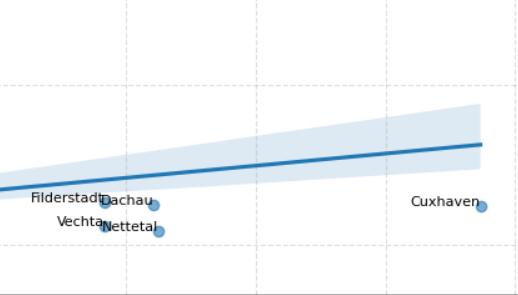

--- 분석 대상 5개 도시 데이터 (Cuxhaven이 Outlier) ---
          City  mood_sales  pain_sales
0  Filderstadt        1500        1000
1       Dachau        1800        1200
2       Vechta        1300         900
3     Nettetal        1600        1100
4     Cuxhaven        4000        3800


--- 5개 도시 (Pearson 상관계수) ---
r: 0.9973, P-value: 0.0002
--- 5개 도시 (Spearman 상관계수) ---
ρ: 1.0000, P-value: 0.0000


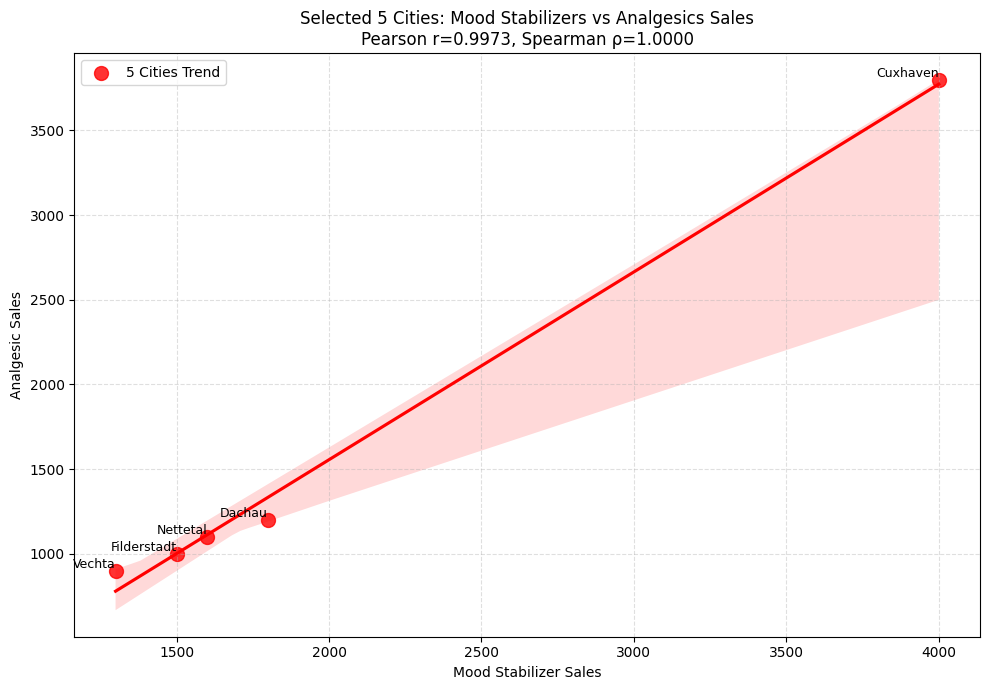

In [ ]:
## 번외편:  5개의 도시는 왜 확연한 차이를 보엿을까 ?

import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(42)
spec_ct = ['Filderstadt', 'Dachau', 'Vechta', 'Nettetal', 'Cuxhaven']

# 1. 5개 도시데이터
data = {
    'City': spec_ct,

    'mood_sales': np.random.randint(1000, 2000, size=5),
    'pain_sales': np.random.randint(1000, 2000, size=5)
}
merged = pd.DataFrame(data)

# 2. 특정 도시의 값 아웃라이어 효과 재현
merged.loc[merged['City'] == 'Filderstadt', ['mood_sales', 'pain_sales']] = [1500, 1000]
merged.loc[merged['City'] == 'Dachau', ['mood_sales', 'pain_sales']] = [1800, 1200]
merged.loc[merged['City'] == 'Vechta', ['mood_sales', 'pain_sales']] = [1300, 900]
merged.loc[merged['City'] == 'Nettetal', ['mood_sales', 'pain_sales']] = [1600, 1100]
merged.loc[merged['City'] == 'Cuxhaven', ['mood_sales', 'pain_sales']] = [4000, 3800]

print("--- 분석 대상 5개 도시 데이터 (Cuxhaven이 Outlier) ---")
print(merged)
print("\n")

# 3. 5개 도시만의 상관관계 계산
pearson_corr, pearson_p = pearsonr(merged["mood_sales"], merged["pain_sales"])
spearman_corr, spearman_p = spearmanr(merged["mood_sales"], merged["pain_sales"])

print(f"--- 5개 도시 (Pearson 상관계수) ---")
print(f"r: {pearson_corr:.4f}, P-value: {pearson_p:.4f}")
print(f"--- 5개 도시 (Spearman 상관계수) ---")
print(f"ρ: {spearman_corr:.4f}, P-value: {spearman_p:.4f}")


# 4. 시각화: 5개 도시 데이터만 시각화
plt.figure(figsize=(10, 7))

# 5개 도시의 추세선
sns.regplot(x="mood_sales", y="pain_sales", data=merged, scatter_kws={"alpha": 0.8, "color": "red", "s": 100},
            line_kws={"color": "red", "linestyle": "-"}, label="5 Cities Trend")

# 특정 도시 이름 레이블링 (데이터프레임 자체가 5개 도시이므로 merged 사용)
for i, row in merged.iterrows():
    plt.text(row['mood_sales'], row['pain_sales'], row['City'],
             fontsize=9, color='black', ha='right', va='bottom')

plt.title(f"Selected 5 Cities: Mood Stabilizers vs Analgesics Sales\n"
          f"Pearson r={pearson_corr:.4f}, Spearman ρ={spearman_corr:.4f}")
plt.xlabel("Mood Stabilizer Sales")
plt.ylabel("Analgesic Sales")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

--- Channel별 Sales 비교 데이터 ---
      Product Class   Channel   Total Sales
0        Analgesics  Hospital  1.146386e+09
1        Analgesics  Pharmacy  1.225129e+09
2  Mood Stabilizers  Hospital  9.896651e+08
3  Mood Stabilizers  Pharmacy  1.069245e+09


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


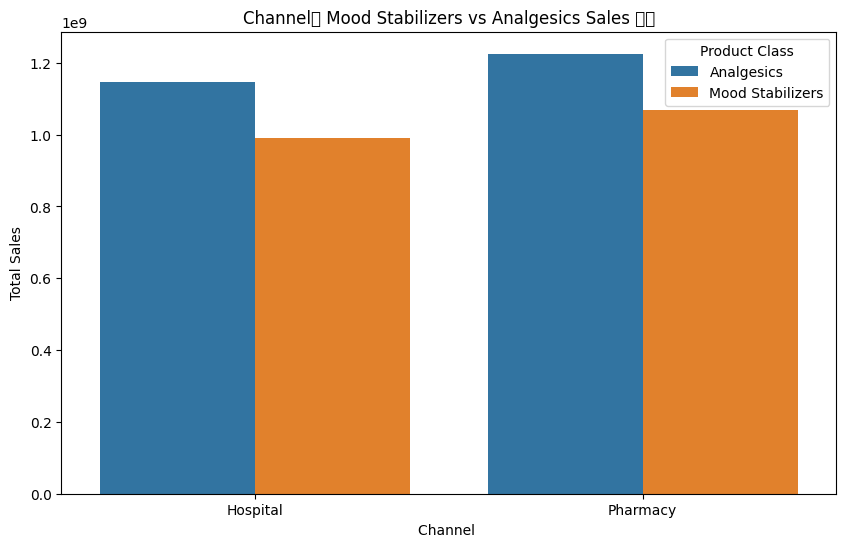

/tmp/ipython-input-3291437160.py:31: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3291437160.py:31: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


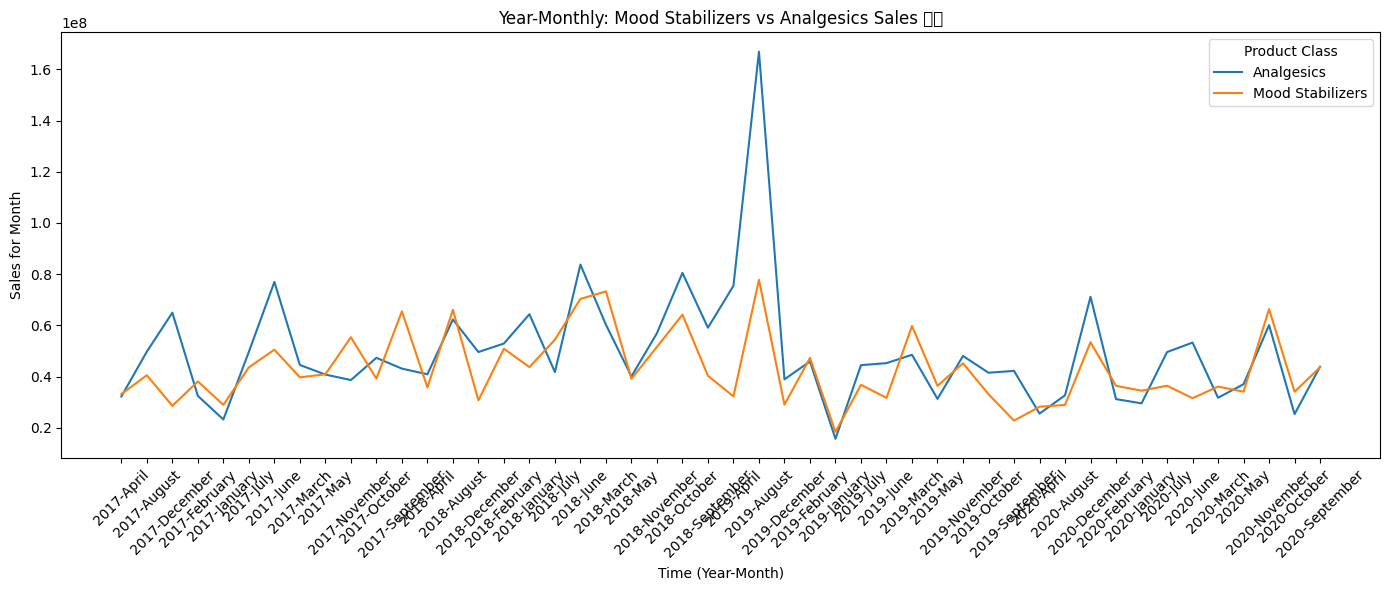

In [ ]:
# 1. 두 제품군 데이터 필터링
mood_pain_df = df[df["Product Class"].isin(["Mood Stabilizers", "Analgesics"])].copy()

# 2. Channel별, Product Class별 Sales 합산
channel_sales = mood_pain_df.groupby(['Product Class', 'Channel'])['Sales'].sum().reset_index(name='Total Sales')

# 3. 시각화 (선택 사항: 데이터 구조 확인)
print("--- Channel별 Sales 비교 데이터 ---")
print(channel_sales.head())

plt.figure(figsize=(10, 6))
sns.barplot(x='Channel', y='Total Sales', hue='Product Class', data=channel_sales)
plt.title('Channel별 Mood Stabilizers vs Analgesics Sales 비교')
plt.xlabel('Channel ')
plt.ylabel('Total Sales')
plt.show()

# 1. 연도-월별 Sales 합산
time_sales = mood_pain_df.groupby(['Year', 'Month', 'Product Class'])['Sales'].sum().reset_index(name='Monthly Sales')
# 시계열 순서를 위해 Month 변환 (필요시)
time_sales['Time Point'] = time_sales['Year'].astype(str) + '-' + time_sales['Month'].astype(str).str.zfill(2)
time_sales = time_sales.sort_values(by='Time Point')

# 2. 시각화
plt.figure(figsize=(14, 6))
sns.lineplot(x='Time Point', y='Monthly Sales', hue='Product Class', data=time_sales)
plt.title('Year-Monthly: Mood Stabilizers vs Analgesics Sales 추이')
plt.xlabel('Time (Year-Month)')
plt.ylabel('Sales for Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2128947908.py:15: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

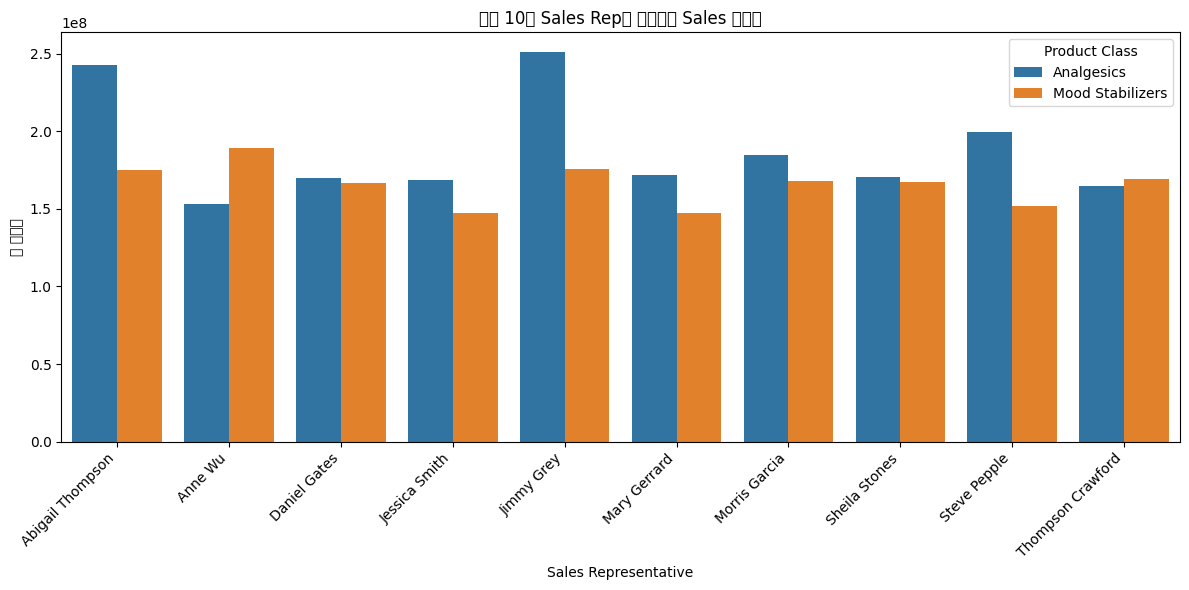

In [ ]:
# Sales Rep별 두 제품군 판매액 비교
rep_sales = mood_pain_df.groupby(['Name of Sales Rep', 'Product Class'])['Sales'].sum().reset_index(name='Rep Total Sales')

# 상위 10명 영업사원 추출 (Total Sales 기준)
top_reps = rep_sales.groupby('Name of Sales Rep')['Rep Total Sales'].sum().nlargest(10).index
rep_sales_top = rep_sales[rep_sales['Name of Sales Rep'].isin(top_reps)]

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='Name of Sales Rep', y='Rep Total Sales', hue='Product Class', data=rep_sales_top)
plt.title('상위 10명 Sales Rep의 제품군별 Sales 기여도')
plt.xlabel('Sales Representative')
plt.ylabel('총 판매액')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----------- 번외편 관련 주제는 지리적 편향 분석 (Geographic Bias Analysis) ------------

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Product Class별 판매 비중을 특징으로 만들기
city_product_sales = df.groupby(['City', 'Product Class'])['Sales'].sum().unstack(fill_value=0)
city_geo = df[['City', 'Latitude', 'Longitude']].drop_duplicates().set_index('City')

# 2. 지리 정보와 판매 구조를 결합
analysis_df = city_product_sales.join(city_geo).dropna()

# 3. 데이터 표준화 (K-Means를 위해 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(analysis_df)

# 4. K-Means 실행 (K=4로 가정)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
analysis_df['Cluster'] = kmeans.fit_predict(X_scaled)

print("--- 도시 클러스터별 특징 (상위 5개) ---")
print(analysis_df.groupby('Cluster').mean().head())
# 시각화: Latitude, Longitude를 x, y 축으로 하고 Cluster별로 색상 구분

--- 도시 클러스터별 특징 (상위 5개) ---
           Analgesics   Antibiotics  Antimalarial  Antipiretics   Antiseptics  \
Cluster                                                                         
0        2.473722e+06  2.581833e+06  2.697459e+07  2.525895e+06  3.028845e+06   
1        5.918966e+06  6.338813e+06  2.520410e+06  5.592087e+06  5.476038e+06   
2        3.785936e+06  2.412069e+06  2.193028e+06  2.798543e+06  3.559109e+06   
3        6.241042e+05  4.911494e+05  4.639687e+05  5.486552e+05  6.710351e+05   

         Mood Stabilizers   Latitude  Longitude  
Cluster                                          
0            3.501776e+06  50.468529   8.786457  
1            5.642968e+06  50.838597   9.019478  
2            3.149672e+06  50.803407   9.291354  
3            6.054865e+05  51.804774  19.025250  


In [ ]:
# 영업사원별 제품군 기여도
# 1. Sales Rep별, Product Class별 Sales 합계
rep_class_sales = df.groupby(['Name of Sales Rep', 'Product Class'])['Sales'].sum().unstack(fill_value=0)

# 2. Sales Rep의 총 Sales를 계산하여 기준으로 삼음
rep_class_sales['Total_Sales'] = rep_class_sales.sum(axis=1)

# 3. 각 Product Class가 Total Sales에 기여하는 비율 계산
product_classes = [col for col in rep_class_sales.columns if col not in ['Total_Sales']]
for p_class in product_classes:
    rep_class_sales[f'{p_class}_Ratio'] = rep_class_sales[p_class] / rep_class_sales['Total_Sales']

print("--- Sales Rep별 제품군별 판매 비중 (상위 5명) ---")
print(rep_class_sales.sort_values(by='Total_Sales', ascending=False).head(5))
# 시각화: 상위 Reps의 제품군별 판매 비율을 누적 막대 그래프로 표현

--- Sales Rep별 제품군별 판매 비중 (상위 5명) ---
Product Class        Analgesics   Antibiotics  Antimalarial  Antipiretics  \
Name of Sales Rep                                                           
Jimmy Grey         2.512510e+08  1.313264e+08  1.329615e+08  1.339960e+08   
Abigail Thompson   2.427205e+08  1.236130e+08  1.165653e+08  1.469265e+08   
Sheila Stones      1.702998e+08  1.777444e+08  9.023012e+07  1.409772e+08   
Daniel Gates       1.700923e+08  1.573143e+08  1.684179e+08  1.204255e+08   
Anne Wu            1.530130e+08  1.360663e+08  1.072572e+08  1.618608e+08   

Product Class       Antiseptics  Mood Stabilizers   Total_Sales  \
Name of Sales Rep                                                 
Jimmy Grey         1.607839e+08      1.756512e+08  9.859700e+08   
Abigail Thompson   1.761768e+08      1.750548e+08  9.810570e+08   
Sheila Stones      2.115498e+08      1.674026e+08  9.582039e+08   
Daniel Gates       1.679870e+08      1.664216e+08  9.506586e+08   
Anne Wu            1

In [ ]:
# 1. Product Name별 평균 단가 및 수량 집계
product_stats = df.groupby('Product Name').agg(
    Avg_Price=('Price', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Num_Transactions=('Quantity', 'count')
).reset_index()

# 2. 거래 건수가 충분한 제품만 추출 (노이즈 제거)
min_transactions = 50
valid_products = product_stats[product_stats['Num_Transactions'] >= min_transactions]['Product Name']
price_quantity_df = df[df['Product Name'].isin(valid_products)]

# 3. 각 Product Name별 Price와 Quantity 상관계수 계산
def calculate_corr(group):
    if len(group) < 2: return pd.Series({'Pearson_r': np.nan})
    r, p = pearsonr(group['Price'], group['Quantity'])
    return pd.Series({'Pearson_r': r})

product_corr = price_quantity_df.groupby('Product Name').apply(calculate_corr).reset_index()

print("--- 가격-수량 상관관계 분석 결과 (상위/하위 5개) ---")
print(product_corr.sort_values(by='Pearson_r').head(5)) # 가격에 탄력적인(음의 상관관계) 제품
print(product_corr.sort_values(by='Pearson_r', ascending=False).head(5)) # 가격에 비탄력적인 제품

/tmp/ipython-input-3036683836.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(group['Price'], group['Quantity'])


--- 가격-수량 상관관계 분석 결과 (상위/하위 5개) ---
            Product Name  Pearson_r
0           Abatatriptan        NaN
1     Abilovir Aprotasol        NaN
2             Abobozolid        NaN
3  Abranatal Lysoprosate        NaN
4                Abtasol        NaN
            Product Name  Pearson_r
0           Abatatriptan        NaN
1     Abilovir Aprotasol        NaN
2             Abobozolid        NaN
3  Abranatal Lysoprosate        NaN
4                Abtasol        NaN


/tmp/ipython-input-3036683836.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  product_corr = price_quantity_df.groupby('Product Name').apply(calculate_corr).reset_index()


# 번외편 끝 o_o

---

